# STAT 207 Group Lab Assignment 4 - [10 total points]

## Populations & Samples

<hr>

## <u>Lab Grading</u>:

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

If you said **my submission is under netID** above, we will not read any more of your lab submission.

If you said **grade this submission** above, who worked with you on this submission?  Write both their **names** and **netIDs**.  Also, include the most recent fast food restaurant that you've eaten at.

<hr>

## <u>Purpose</u>:
You should work in groups of 2-3 on this report (not working in groups without permission will result in a point deduction). The purpose of this group lab assignment is to consider the differences between populations and samples and to explore the presence of missing data.
<hr>

## <u>Assignment Instructions</u>:

### Group Roles

Suggested and specified roles are provided below: 

#### Groups of 2

* **Driver**: This student will type the report.  While typing the report, you may be the one who is selecting the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  Specific ways to help may include: outlining the general steps needed to solve a question (providing the overview), locating examples within the course notes, and reviewing each line of code as it is typed.

#### Groups of 3

* **Driver**: This student will type the report.  They may also be the one to select the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  They may select the general approach to answering the question and/or a few steps to be completed along the way. 
* **Communicator**: This student will review the report (as it is typed) to ensure that it is clear and concise.  This student may also locate relevant examples within the course notes that may help complete the assignment.

<hr>

### Imports

In [1]:
#Run this
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()  

## Case Study: Controlling Sodium

For many health conditions, controlling sodium intake is an important goal.  However, many Americans regularly eat at fast-food restaurants.  For these Americans, we'd like to be able to suggest menu items that might have limited sodium, especially if the sodium measure is not easily available, based on other nutritional information of that item.  For this Case Study, we will learn about the **sodium** content of menu items at fast-food restaurants.

We will use the following nutritional information about menu items:

- **restaurant**: the restaurant of the menu item
- **item**: the name of the menu item, which provides information to help define our observational unit
- **calories**: the number of calories
- **cal_fat**: the calories from fat
- **total_fat**: the total fat
- **sat_fat**: the saturated fat
- **trans_fat**: the trans fat
- **cholesterol**: the cholesterol
- **total_carb**: the total carbohydrates
- **fiber**: the fiber
- **sugar**: the sugar
- **protein**: the protein
- **vit_a**: the Vitamin A
- **vit_c**: the Vitamin C
- **calcium**: the calcium

Note that observational information is included for each menu item, including the restaurant and the item name.  The data originally came from https://www.kaggle.com/datasets/sujaykapadnis/fast-food-calories-data.

Run the code in the cell below to read in the data for this document.  The data is saved as `df` with this code.  

In [7]:
df = pd.read_csv('fastfood.csv')
df['sodium'].head(10)

0    1110
1    1580
2    1920
3    1940
4    1980
5     950
6     680
7    1040
8    1040
9    1290
Name: sodium, dtype: int64

### 1. [4 points] Samples & Populations

The fast food data contains the nutritional information for entree or main dish items on the menu at each of the fast food restaurants and was scraped from each restaurant's website.

Recall that our goal is to be able to suggest menu items that might have limited sodium, especially since the sodium measure might not be easily available for customers to access.

**a)** Define the population of interest that is implied by our research goal.  Be sure to be specific. [*Note*: there are many possible answers for this question, so we are not looking for just one correct answer.]

Food items and nuitrition info across all major fast food chains

**b)** Based on your definition of the population of interest, would the available data correspond to a population or a sample?  Explain.

The data would correspond to a sample as we do not have all food items and info from all major fast food chains. We do not have food items from Wendy's which would be required in the population data set.

**c)** If you were to calculate a summary measure from your available data, would it be a parameter or a statistic?

Statistic because we have a sample not a population

**d)** Would you consider your available data to be representative of your population of interest?  Briefly explain.  You may choose to explore your data through analysis, although this is not required.

In [ ]:
#It would not be representative of the population because the data systematically excludes some major fast food chains, as well as
# the sample was not randomly sampled which is required to be representative.

**e)** What would you anticipate is the typical amount of sodium contained in a fast food dish for the population that you identified in part **a**?  [*Note*: there are multiple approaches that could be used to answer this question.]

In [8]:
df['sodium'].agg(['mean', 'median', 'std', 'min', 'max'])

mean      1246.737864
median    1110.000000
std        689.954278
min         15.000000
max       6080.000000
Name: sodium, dtype: float64

I would anticipate the average to be around 1100 mg to 1200 mg.

### 2. [6 points] Exploring Missing Data

When performing an analysis, we often decide to drop all observations that have missing values for any of the variables in the data.  In our class, we've used this approach most often, as it's the simplest.  However, I'd like you to evaluate whether you think the decision to remove any observations with missing values is the best course of action for this data, or if it might reduce the representativeness of the available data. 

**a)** First, identify which variables in the data contain missing values, and how many missing values each variable contains.  You may assume that all missing values have already been appropriately identified in the data.

In [16]:
df.isna().sum()

restaurant       0
item             0
calories         0
cal_fat          0
total_fat        0
sat_fat          0
trans_fat        0
cholesterol      0
sodium           0
total_carb       0
fiber           12
sugar            0
protein          1
vit_a          214
vit_c          210
calcium        210
dtype: int64

Fiber contains 12 missing values
Vit_a contains 214 missing values
Vit_c contains 210 missing values
Calcium contains 210 missing values

**b)** Select one of the variables that has missing values.  Create a new boolean variable in the data that records whether a given observation has a missing value recorded.  Note that this may be completed with the `.isna()` method.

In [20]:
df['calcium missing'] = df['calcium'].isna()
df[['calcium missing','sodium']] 

,calcium missing,sodium
0,False,1110
1,False,1580
2,False,1920
3,False,1940
4,False,1980
...,...,...
510,False,1850
511,True,1270
512,True,1340
513,True,1260


**c)** Explore the connection between the missing value for your variable selected and created in part **b** and the sodium variable.  Generate numerical summaries and/or graphs to determine if there is a relationship between the presence of missing values for your variable in the data and the sodium variable.

If you have time, you can repeat this process of exploring the relationship for the missing value of your variable from part **b** and another variable of your choosing in the data.

In [25]:
df.groupby('calcium missing')['sodium'].agg(['mean', 'median', 'std', 'min', 'max'])

,mean,median,std,min,max
calcium missing,,,,,
False,1279.409836,1120.0,733.582916,15,6080
True,1199.285714,1070.0,619.803924,290,4520


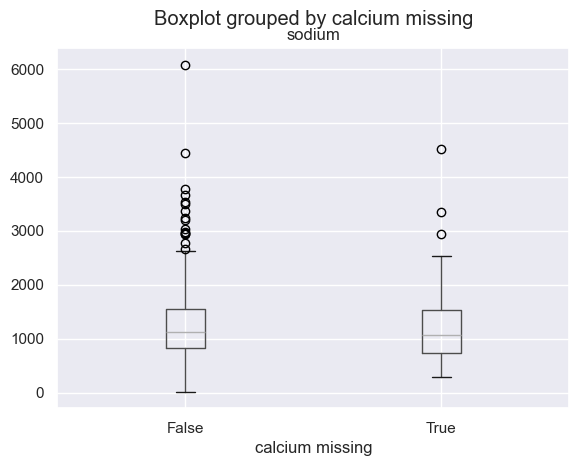

In [ ]:
df.boxplot(column='sodium', by='calcium missing')
plt.show()

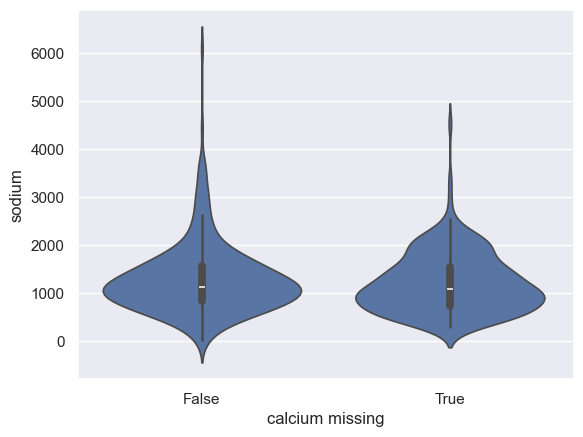

In [32]:
sns.violinplot(x = 'calcium missing', y = 'sodium', data = df)
plt.show()

In [ ]:
df.crosstab = pd.crosstab(df['restaurant'], df['calcium missing'])
print(df.crosstab)

calcium missing  False  True 
restaurant                   
Arbys               25     30
Burger King          0     70
Chick Fil-A         25      2
Dairy Queen         27     15
Mcdonalds           57      0
Sonic               49      4
Subway              96      0
Taco Bell           26     89


**d)** Finally, provide a brief summary for if you think that removing the missing observations reduces the representativeness of the available data, along with a brief justification.

If we drop all missing calcium values we would be systematically removing burger king from our sample reducing the represenativeness of our data. But do note that calcium missing does not seem to differ from the shape where calcium records are present.

### 3. AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  AI should not be used on Questions 1 and 2d of this assignment.  

You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class (intended only for projects).  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

<hr>

If you have extra time during lab, you may consider organizing for Project 1 if still needed (arranging your group and picking your dataset).  You may also use this time to work on the assignment.  Be sure to read the Project 1 instructions carefully as you complete the project.